In [1]:
#Import Librarirs

In [32]:
import pandas as pd

loans = pd.read_csv(
    "accepted_2007_to_2018Q4.csv",
    nrows=100000,
    low_memory=False
)

In [33]:
loans.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
loans.shape

(100000, 151)

In [35]:
macro = pd.read_csv("combined_fred_monthly.csv")
macro.head()

,Date,Unemployment_Rate,Federal_Funds_Rate,CPI_Index,Inflation_YoY_Pct,Real_Disposable_Income,Real_Disposable_Income_YoY_Pct,Personal_Saving_Rate,Credit_Card_Delinquency_Rate,Home_Price_Index,Home_Price_YoY_Pct,Real_GDP,Real_GDP_QoQ_Annualized_Pct
0,1991-01-01,6.4,6.91,134.7,5.647059,7205.7,0.254612,9.4,5.26,75.913,-1.279634,9951.916,-1.858665
1,1991-02-01,6.6,6.25,134.8,5.312500,7216.8,0.187414,9.0,5.26,75.732,-1.713129,9951.916,NaN
2,1991-03-01,6.8,6.12,134.8,4.821151,7229.1,0.319174,8.1,5.26,75.564,-2.119171,9951.916,NaN
3,1991-04-01,6.7,5.91,135.1,4.809930,7258.0,0.063419,8.7,5.48,75.564,-2.216701,10029.510,3.155421
4,1991-05-01,6.9,5.78,135.6,5.034857,7259.5,0.189075,8.5,5.48,75.761,-1.988408,10029.510,NaN


In [36]:
loans[["issue_d"]].head()

,issue_d
0,Dec-2015
1,Dec-2015
2,Dec-2015
3,Dec-2015
4,Dec-2015


In [37]:
macro.head()

,Date,Unemployment_Rate,Federal_Funds_Rate,CPI_Index,Inflation_YoY_Pct,Real_Disposable_Income,Real_Disposable_Income_YoY_Pct,Personal_Saving_Rate,Credit_Card_Delinquency_Rate,Home_Price_Index,Home_Price_YoY_Pct,Real_GDP,Real_GDP_QoQ_Annualized_Pct
0,1991-01-01,6.4,6.91,134.7,5.647059,7205.7,0.254612,9.4,5.26,75.913,-1.279634,9951.916,-1.858665
1,1991-02-01,6.6,6.25,134.8,5.312500,7216.8,0.187414,9.0,5.26,75.732,-1.713129,9951.916,NaN
2,1991-03-01,6.8,6.12,134.8,4.821151,7229.1,0.319174,8.1,5.26,75.564,-2.119171,9951.916,NaN
3,1991-04-01,6.7,5.91,135.1,4.809930,7258.0,0.063419,8.7,5.48,75.564,-2.216701,10029.510,3.155421
4,1991-05-01,6.9,5.78,135.6,5.034857,7259.5,0.189075,8.5,5.48,75.761,-1.988408,10029.510,NaN


In [38]:
macro.columns

Index(['Date', 'Unemployment_Rate', 'Federal_Funds_Rate', 'CPI_Index',
       'Inflation_YoY_Pct', 'Real_Disposable_Income',
       'Real_Disposable_Income_YoY_Pct', 'Personal_Saving_Rate',
       'Credit_Card_Delinquency_Rate', 'Home_Price_Index',
       'Home_Price_YoY_Pct', 'Real_GDP', 'Real_GDP_QoQ_Annualized_Pct'],
      dtype='object')

In [39]:
loans["issue_d"] = pd.to_datetime(loans["issue_d"], format="%b-%Y")
macro["Date"] = pd.to_datetime(macro["Date"])

loans["month"] = loans["issue_d"].dt.to_period("M").dt.to_timestamp()
macro["month"] = macro["Date"].dt.to_period("M").dt.to_timestamp()

In [40]:
loans[["issue_d", "month"]].head()

,issue_d,month
0,2015-12-01,2015-12-01
1,2015-12-01,2015-12-01
2,2015-12-01,2015-12-01
3,2015-12-01,2015-12-01
4,2015-12-01,2015-12-01


In [41]:
macro[["Date", "month"]].head()

,Date,month
0,1991-01-01,1991-01-01
1,1991-02-01,1991-02-01
2,1991-03-01,1991-03-01
3,1991-04-01,1991-04-01
4,1991-05-01,1991-05-01


In [42]:
fused = pd.merge(loans, macro, on="month", how="left")

In [43]:
fused.shape

(100000, 165)

In [44]:
fused.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,CPI_Index,Inflation_YoY_Pct,Real_Disposable_Income,Real_Disposable_Income_YoY_Pct,Personal_Saving_Rate,Credit_Card_Delinquency_Rate,Home_Price_Index,Home_Price_YoY_Pct,Real_GDP,Real_GDP_QoQ_Annualized_Pct
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,237.761,0.638725,14060.2,2.486315,5.8,2.16,176.517,5.046508,18892.206,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,237.761,0.638725,14060.2,2.486315,5.8,2.16,176.517,5.046508,18892.206,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,237.761,0.638725,14060.2,2.486315,5.8,2.16,176.517,5.046508,18892.206,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,237.761,0.638725,14060.2,2.486315,5.8,2.16,176.517,5.046508,18892.206,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,237.761,0.638725,14060.2,2.486315,5.8,2.16,176.517,5.046508,18892.206,NaN


In [45]:
fused.to_csv("fused_lendingclub_fred.csv", index=False)

In [46]:
fused[[
    "Unemployment_Rate",
    "Federal_Funds_Rate",
    "CPI_Index",
    "Inflation_YoY_Pct",
    "Real_Disposable_Income",
    "Personal_Saving_Rate",
    "Credit_Card_Delinquency_Rate",
    "Home_Price_Index",
    "Real_GDP"
]].isna().sum()

Unemployment_Rate               0
Federal_Funds_Rate              0
CPI_Index                       0
Inflation_YoY_Pct               0
Real_Disposable_Income          0
Personal_Saving_Rate            0
Credit_Card_Delinquency_Rate    0
Home_Price_Index                0
Real_GDP                        0
dtype: int64

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


AttributeError: module 'numpy._globals' has no attribute '_signature_descriptor'

ImportError: cannot load module more than once per process

ImportError: cannot load module more than once per process

ImportError: cannot load module more than once per process

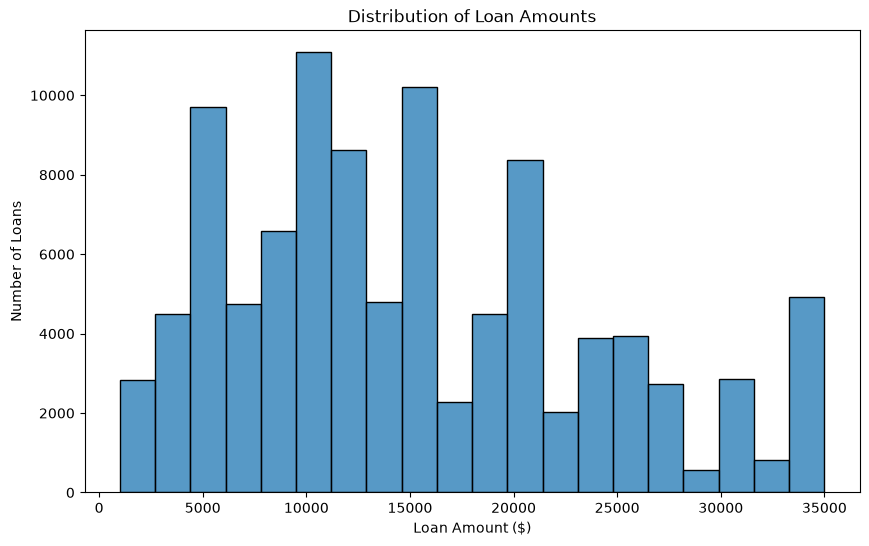

In [18]:
plt.figure(figsize=(10,6))
sns.histplot(fused["loan_amnt"], bins=20)
plt.title("Distribution of Loan Amounts")
plt.xlabel("Loan Amount ($)")
plt.ylabel("Number of Loans")
plt.savefig("loan_amount_distribution.png")
plt.show()

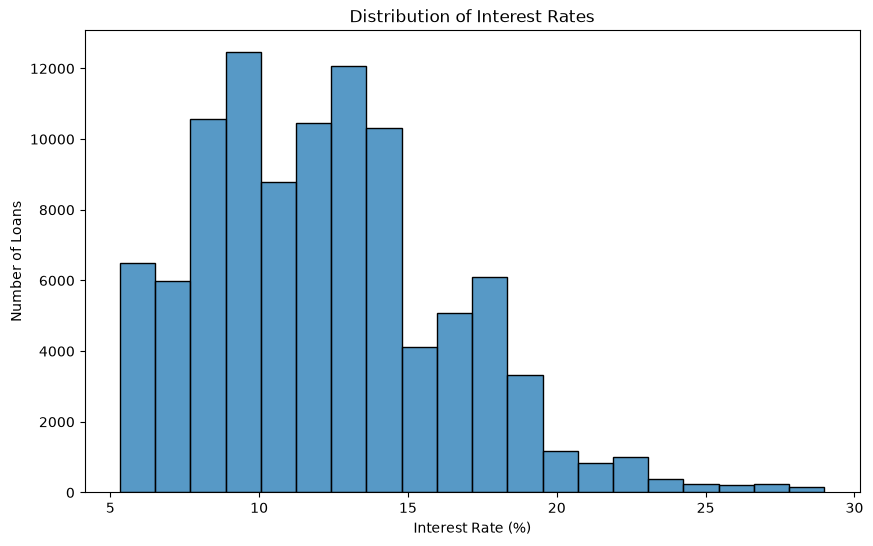

In [19]:
plt.figure(figsize=(10,6))
sns.histplot(fused["int_rate"], bins=20)
plt.title("Distribution of Interest Rates")
plt.xlabel("Interest Rate (%)")
plt.ylabel("Number of Loans")
plt.savefig("interest_rate_distribution.png")
plt.show()

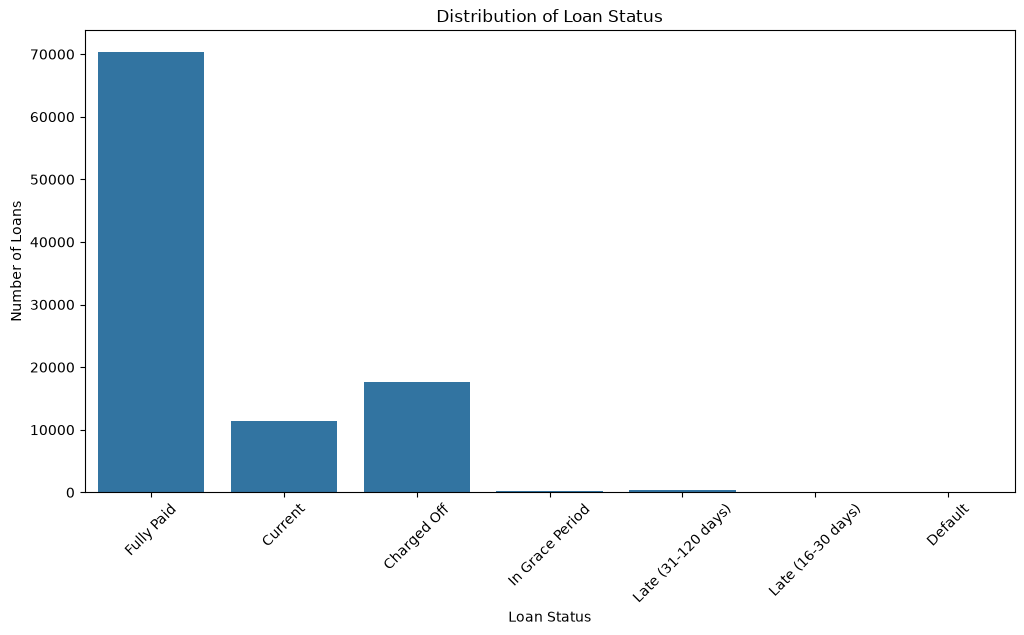

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(data=fused, x="loan_status")
plt.xticks(rotation=45)
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.savefig("loan_status_distribution.png")
plt.show()

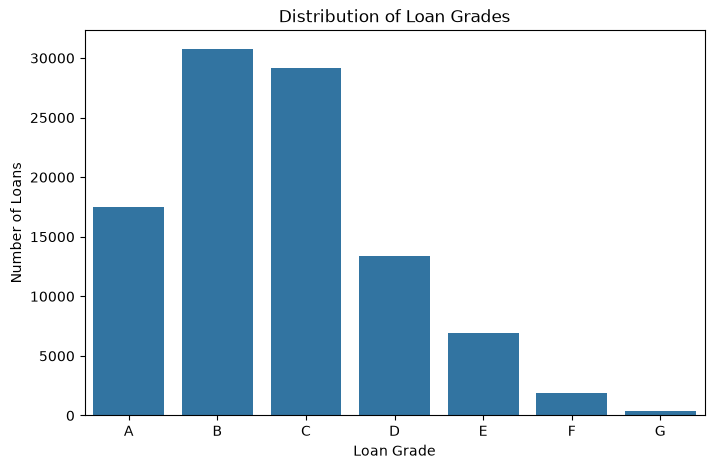

In [21]:
plt.figure(figsize=(8,5))
sns.countplot(data=fused, x="grade", order=sorted(fused["grade"].dropna().unique()))
plt.title("Distribution of Loan Grades")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Loans")
plt.savefig("loan_grade_distribution.png")
plt.show()

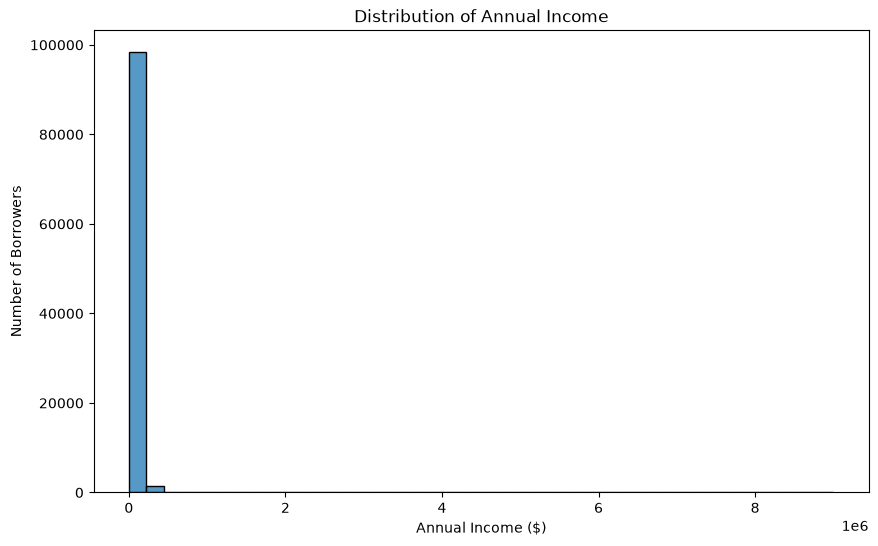

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(fused["annual_inc"], bins=40)
plt.title("Distribution of Annual Income")
plt.xlabel("Annual Income ($)")
plt.ylabel("Number of Borrowers")
plt.savefig("annual_income_distribution.png")
plt.show()

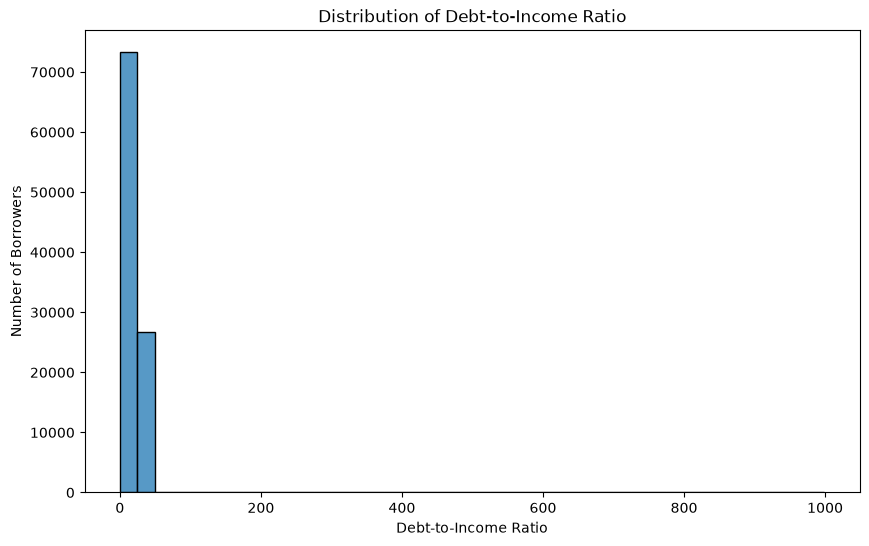

In [23]:
plt.figure(figsize=(10,6))
sns.histplot(fused["dti"], bins=40)
plt.title("Distribution of Debt-to-Income Ratio")
plt.xlabel("Debt-to-Income Ratio")
plt.ylabel("Number of Borrowers")
plt.savefig("dti_distribution.png")
plt.show()

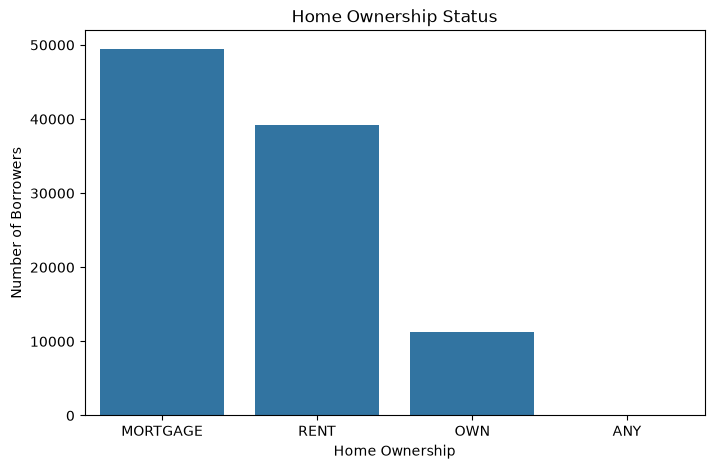

In [24]:
plt.figure(figsize=(8,5))
sns.countplot(data=fused, x="home_ownership")
plt.title("Home Ownership Status")
plt.xlabel("Home Ownership")
plt.ylabel("Number of Borrowers")
plt.savefig("home_ownership.png")
plt.show()

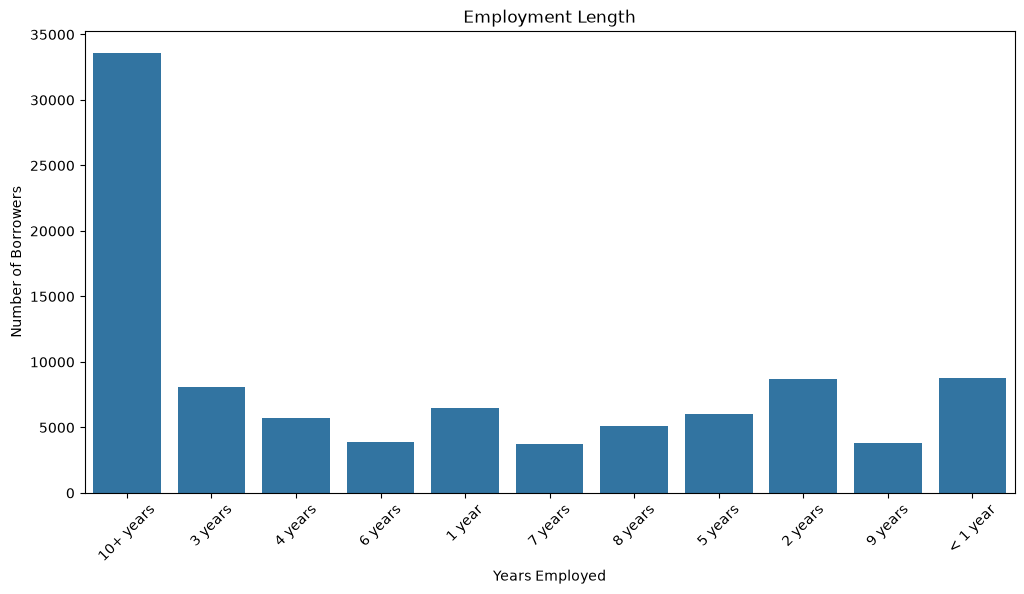

In [25]:
plt.figure(figsize=(12,6))
sns.countplot(data=fused, x="emp_length")
plt.xticks(rotation=45)
plt.title("Employment Length")
plt.xlabel("Years Employed")
plt.ylabel("Number of Borrowers")
plt.savefig("employment_length.png")
plt.show()

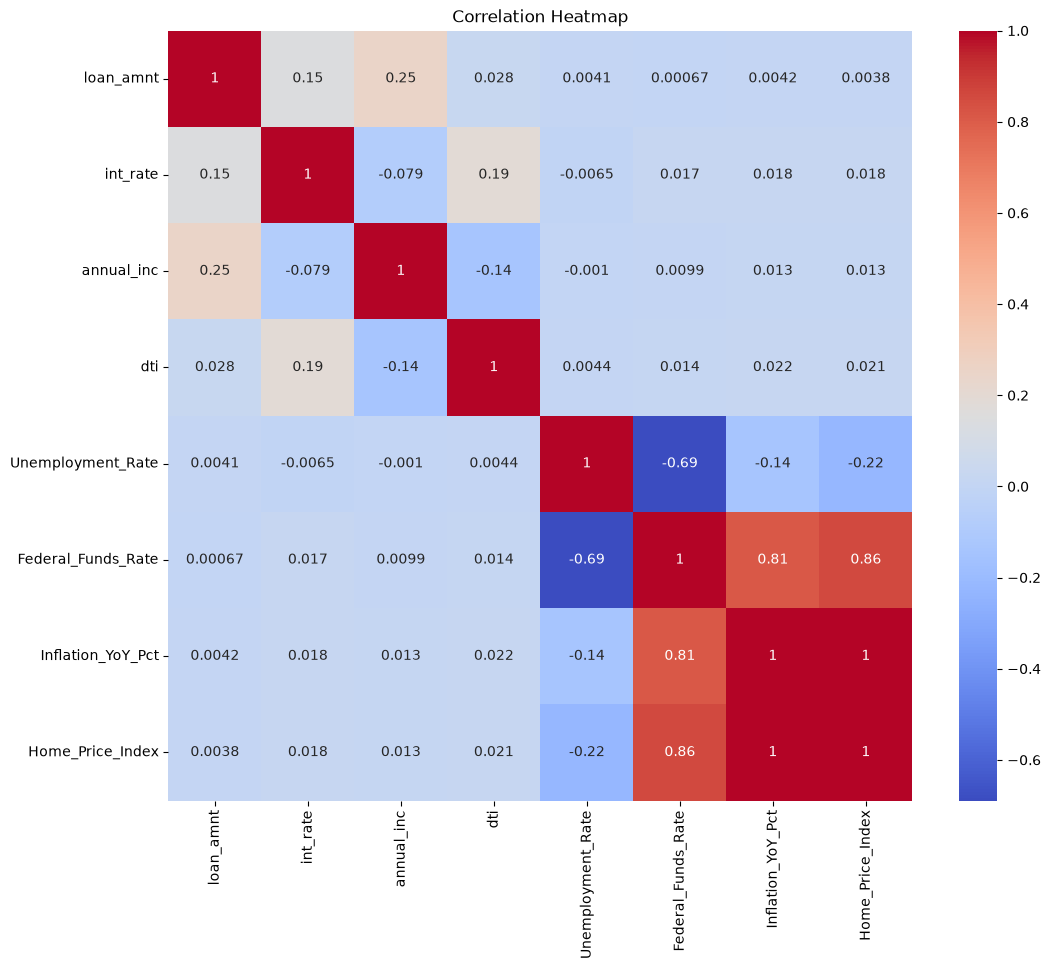

In [26]:
plt.figure(figsize=(12,10))

cols = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "Unemployment_Rate",
    "Federal_Funds_Rate",
    "Inflation_YoY_Pct",
    "Home_Price_Index"
]

sns.heatmap(
    fused[cols].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

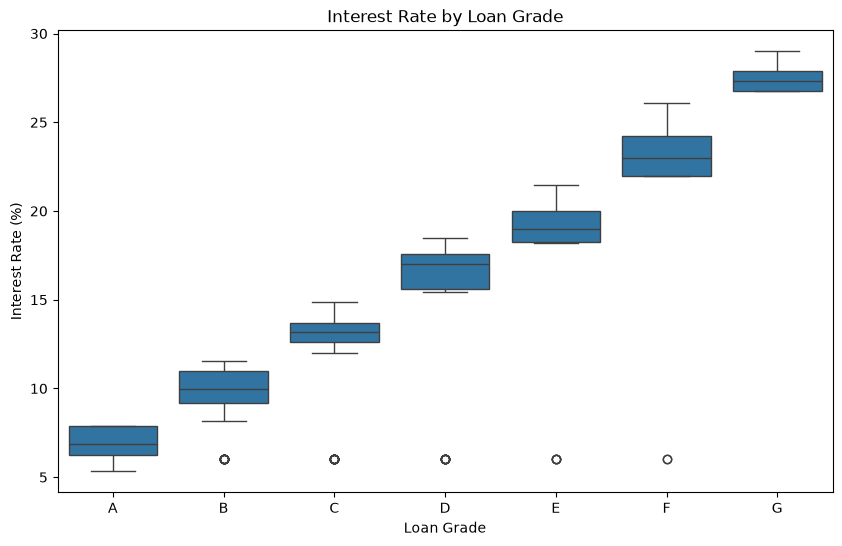

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=fused,
    x="grade",
    y="int_rate",
    order=sorted(fused["grade"].dropna().unique())
)

plt.title("Interest Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Interest Rate (%)")
plt.savefig("interest_rate_by_grade.png")
plt.show()

In [28]:
!pip install xgboost

In [29]:
import pandas as pd
import numpy as np

model_data = fused.copy()

# Keep only loans with clear final outcomes
model_data = model_data[model_data["loan_status"].isin(["Fully Paid", "Charged Off"])]

# Target variable: 1 = default/charged off, 0 = fully paid
model_data["default"] = model_data["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

In [30]:
features = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "grade",
    "home_ownership",
    "purpose",
    "emp_length",
    "Unemployment_Rate",
    "Federal_Funds_Rate",
    "Inflation_YoY_Pct",
    "Personal_Saving_Rate",
    "Credit_Card_Delinquency_Rate",
    "Home_Price_Index",
    "Real_GDP"
]

X = model_data[features]
y = model_data["default"]

In [31]:
from sklearn.model_selection import train_test_split

# First split: 20% testing, 80% remaining
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: from the remaining 80%, take 25% for validation
# This gives 60% train, 20% validation, 20% test overall
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Testing set:", X_test.shape)

ImportError: cannot load module more than once per process

ImportError: numpy._core.multiarray failed to import

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

numeric_features = [
    "loan_amnt",
    "int_rate",
    "annual_inc",
    "dti",
    "Unemployment_Rate",
    "Federal_Funds_Rate",
    "Inflation_YoY_Pct",
    "Personal_Saving_Rate",
    "Credit_Card_Delinquency_Rate",
    "Home_Price_Index",
    "Real_GDP"
]

categorical_features = [
    "grade",
    "home_ownership",
    "purpose",
    "emp_length"
]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

log_reg_model.fit(X_train, y_train)

log_pred = log_reg_model.predict(X_test)
log_prob = log_reg_model.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
from xgboost import XGBClassifier

# Preprocess the data manually so we can use validation data for early stopping
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

# Final XGBoost model with 1000 estimators and early stopping
xgb_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="logloss",
    early_stopping_rounds=30
)

# Train using validation set
xgb_model.fit(
    X_train_processed,
    y_train,
    eval_set=[(X_val_processed, y_val)],
    verbose=True
)

# Predict on final test set
xgb_pred = xgb_model.predict(X_test_processed)
xgb_prob = xgb_model.predict_proba(X_test_processed)[:, 1]

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, log_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, log_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, log_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, log_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

results

In [ ]:
model_data["loan_status"].value_counts()

In [ ]:
import xgboost
print(xgboost.__version__)

In [ ]:
print("Best iteration:", xgb_model.best_iteration)
print("Best validation score:", xgb_model.best_score)

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

cm = np.array([
    [13795, 263],
    [3164, 357]
])

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size": 14, "color": "black"},
    xticklabels=["Fully Paid", "Charged Off"],
    yticklabels=["Fully Paid", "Charged Off"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
print(cm)

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, xgb_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="blue", label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend(loc="lower right")

plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, xgb_prob)
ap = average_precision_score(y_test, xgb_prob)

plt.figure(figsize=(6,5))

plt.plot(recall, precision,
         color="darkorange",
         label=f"Average Precision = {ap:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - XGBoost")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=15
)

plt.title("Top 15 Most Important Features")
plt.show()

In [ ]:
import joblib

joblib.dump(xgb_model, "xgboost_final_model.pkl")

print("Model saved successfully!")

In [ ]:
#Ablation Study

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

def run_xgb_ablation(feature_list, label):
    X_ablation = model_data[feature_list]
    y_ablation = model_data["default"]

    X_temp, X_test_a, y_temp, y_test_a = train_test_split(
        X_ablation, y_ablation,
        test_size=0.20,
        random_state=42,
        stratify=y_ablation
    )

    X_train_a, X_val_a, y_train_a, y_val_a = train_test_split(
        X_temp, y_temp,
        test_size=0.25,
        random_state=42,
        stratify=y_temp
    )

    numeric_a = [col for col in numeric_features if col in feature_list]
    categorical_a = [col for col in categorical_features if col in feature_list]

    preprocessor_a = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_a),
            ("cat", categorical_transformer, categorical_a)
        ]
    )

    X_train_proc = preprocessor_a.fit_transform(X_train_a)
    X_val_proc = preprocessor_a.transform(X_val_a)
    X_test_proc = preprocessor_a.transform(X_test_a)

    model = XGBClassifier(
        n_estimators=1000,
        learning_rate=0.1,
        max_depth=4,
        random_state=42,
        eval_metric="logloss",
        early_stopping_rounds=30
    )

    model.fit(
        X_train_proc,
        y_train_a,
        eval_set=[(X_val_proc, y_val_a)],
        verbose=False
    )

    pred = model.predict(X_test_proc)
    prob = model.predict_proba(X_test_proc)[:, 1]

    return {
        "Experiment": label,
        "Accuracy": accuracy_score(y_test_a, pred),
        "Precision": precision_score(y_test_a, pred),
        "Recall": recall_score(y_test_a, pred),
        "F1 Score": f1_score(y_test_a, pred),
        "ROC-AUC": roc_auc_score(y_test_a, prob),
        "Best Iteration": model.best_iteration
    }

In [ ]:
fred_features = [
    "Unemployment_Rate",
    "Federal_Funds_Rate",
    "Inflation_YoY_Pct",
    "Personal_Saving_Rate",
    "Credit_Card_Delinquency_Rate",
    "Home_Price_Index",
    "Real_GDP"
]

lendingclub_only = [f for f in features if f not in fred_features]

ablation_results = []

ablation_results.append(run_xgb_ablation(features, "Full Model"))
ablation_results.append(run_xgb_ablation(lendingclub_only, "Without FRED Variables"))
ablation_results.append(run_xgb_ablation([f for f in features if f != "int_rate"], "Without Interest Rate"))
ablation_results.append(run_xgb_ablation([f for f in features if f != "grade"], "Without Grade"))
ablation_results.append(run_xgb_ablation([f for f in features if f != "dti"], "Without DTI"))
ablation_results.append(run_xgb_ablation([f for f in features if f != "annual_inc"], "Without Annual Income"))

ablation_df = pd.DataFrame(ablation_results)

ablation_df

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=ablation_df,
    x="Experiment",
    y="ROC-AUC"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=ablation_df,
    x="Experiment",
    y="ROC-AUC"
)

plt.ylim(0.715, 0.726)      # Zoom in so differences are visible

plt.xticks(rotation=35, ha="right")
plt.title("Ablation Study: Effect of Removing Features on ROC-AUC")
plt.ylabel("ROC-AUC")
plt.xlabel("Experiment")

plt.tight_layout()
plt.show()

In [ ]:
#Shap Visability

In [ ]:
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print("NumPy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", sns.__version__)

In [1]:
import sys
print(sys.executable)

/opt/anaconda3/envs/loanpaper/bin/python


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("NumPy:", np.__version__)

NumPy: 1.26.4


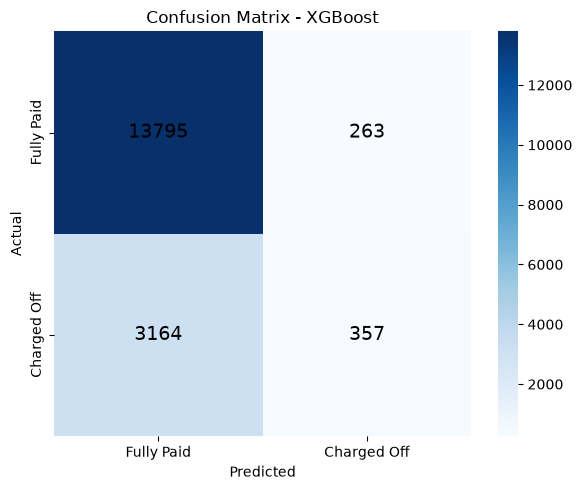

In [3]:
cm = np.array([
    [13795, 263],
    [3164, 357]
])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    annot_kws={"size": 14, "color": "black"},
    xticklabels=["Fully Paid", "Charged Off"],
    yticklabels=["Fully Paid", "Charged Off"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()